In [2]:
!pip install textblob textstat seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.0 MB/s eta 0:00:00


In [3]:
import polars as pl
import polars.selectors as cs
import numpy as np
from textblob import TextBlob
from tqdm import tqdm
import textstat
import seaborn as sns
import joblib
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

In [33]:
import random
import torch as tch
from torch.distributions import Categorical
import torch.nn.functional as F
import string
from transformers import (
    PreTrainedConfig,
    RobertaModel,
    RobertaTokenizer,
    AutoModelForMaskedLM,
    AutoConfig,
)
import numpy as np
from textblob import TextBlob
import textstat
import joblib
import math
import re

def pertubating_text_logits(logits: tch.Tensor, target_ids: tch.Tensor, prob_temp: float = 0.8, sampling_temp: float = 1.2) -> tuple[tch.Tensor, tch.Tensor]:
    perterbated_probs = F.softmax(logits / sampling_temp, dim=-1)
    org_probs = F.log_softmax(logits / prob_temp, dim=-1)

    org_token_probs = tch.gather(org_probs, 2, target_ids).squeeze(-1)
    dist = Categorical(probs=perterbated_probs[0])
    n_sample = 5000
    perterbated_samples = dist.sample((n_sample, )).unsqueeze(-1)

    perterbated_token_probs = tch.gather(org_probs.expand(n_sample, -1, -1), 2, perterbated_samples).squeeze(-1)

    # ep = 1e-10
    # [1, probs], [n_sample, probs]
    return org_token_probs, perterbated_token_probs.mean(dim=-1)

class FastGptDetect:
    def __init__(self, model="roberta-base") -> None:
        # model_name = "roberta-large-mnli"
        print("load model: " + model)
        self.device = tch.device("cuda" if tch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        self.configuration: PreTrainedConfig = AutoConfig.from_pretrained(
            model
        )
        self.tokenizer: RobertaTokenizer = RobertaTokenizer.from_pretrained(
            model, config=self.configuration
        )
        self.model: RobertaModel = AutoModelForMaskedLM.from_pretrained(
            model, config=self.configuration
        )
        self.model.to(self.device)

    def _samples_probs(self, inputs, sample: float) -> tuple[tch.Tensor, tch.Tensor]:
        # perterbating text
        inputs_input_ids: tch.Tensor = inputs['input_ids']
        masked_inputs = inputs_input_ids.clone()
        n = math.ceil(inputs_input_ids.shape[-1] * sample)

        masked_indexes = random.sample(range(inputs_input_ids.shape[-1]), n)
        masked_indexes.sort()
        for i in masked_indexes:
            masked_inputs[0][i] = self.tokenizer.mask_token_id

        with tch.no_grad():
            masked_logits = self.model(input_ids=masked_inputs, attention_mask=inputs['attention_mask'], use_cache=False).logits[:, masked_indexes, :]

        target_ids = inputs_input_ids[:, masked_indexes]

        return masked_logits, target_ids


    def get_text_logits(self, input: str, sample: float) -> tuple[tch.Tensor, tch.Tensor]:
        logits = []
        target_ids = []
        inputs = self.tokenizer(
            input,
            # max_length=configuration.max_position_embeddings - 2,
            return_tensors="pt"
        )

        inputs = inputs.to(self.device)
        max_position_token = self.configuration.max_position_embeddings - 2
        idx = 0
        while idx < inputs.input_ids.shape[1]:
            inputs_current = {
                'input_ids': inputs.input_ids[:, idx:idx+max_position_token],
                'attention_mask': inputs.attention_mask[:, idx:idx+max_position_token],
            }
            masked_logist, masked_target_ids = self._samples_probs(inputs_current, sample)
            logits.append(masked_logist)
            target_ids.append(masked_target_ids)

            idx += inputs_current['input_ids'].shape[1]

        logits = tch.cat(logits, dim=1)
        target_ids = tch.cat(target_ids, dim=-1)

        # [change_seq, logit], [1, change_seq]
        return logits, target_ids

    def sample_perturbate_text(self, input: str, sample: float, temps: list[tuple[float, float]]):
        org_probs = []
        perturbated_probs = []

        logits, target_ids = self.get_text_logits(input, sample)
        target_ids = target_ids.unsqueeze(-1)

        for prob_temp, sampling_temp in temps:
            org_token_probs, perturbated_token_probs = pertubating_text_logits(logits, target_ids, prob_temp=prob_temp, sampling_temp=sampling_temp)
            org_probs.append(org_token_probs)
            perturbated_probs.append(perturbated_token_probs)

        # [feat, probs], [feat, n_sample, probs]
        # [feat, probs], [feat, probs]
        return list(zip(org_probs, perturbated_probs))

    def get_base_features(self, text: str):
        tokens = self.tokenizer(text)
        ttr = calculate_ttr(tokens)
        punct = calc_punctuation(text, "-") / len(text)
        sentence_std = calculate_sentence_length_std(text)
        text_blob = TextBlob(text)
        polarity = text_blob.polarity
        subjectivity = text_blob.subjectivity
        flesch = textstat.flesch_reading_ease(text)
        gunning_fog = textstat.gunning_fog(text)

        base_features = [
            ttr,
            punct,
            sentence_std,
            polarity,
            subjectivity,
            flesch,
            gunning_fog,
        ]

        return base_features

    def predict(self, text: str):
        value = self.sample_perturbate_text(text, 0.2, [
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
            (0.8, 1.0), (0.8, 1.2), (1.0, 2.0), (1.0, 2.5), (1.0, 3.0), (1.0, 5.0),
        ])
        fast_gpts_1 = [get_sampling_discrepancy(log[0], log[1]) for log in value]

        # fast_gpts_1 = [tensor.detach().cpu() for tensor in fast_gpts_1]
        # return np.array(fast_gpts_1).reshape(14, 12).mean(axis=0)
        return tch.stack(fast_gpts_1).reshape(14, 12).mean(dim=0)


def get_sampling_discrepancy(org_x: tch.Tensor, perturbation_x: tch.Tensor):
    r"""
        org_x: [seq]
        perturbation_x: [n_samples, seq]
    """
    # ep = 1e-10
    org_x_log = org_x
    perturbation_x_log = perturbation_x

    multitude = perturbation_x_log.mean()
    org_mul = org_x_log.mean()
    # perplexity = (-org_mul).exp()

    perturbation_std = perturbation_x_log.std()
    # score = (org_x_log - multitude).mean() / perturbation_std
    score = (org_mul - multitude) / perturbation_std
    # score = (org_x_log - multitude).mean()
    return tch.tensor([score, perturbation_std])



def calculate_ttr(text_tokens):
    """Calculates the Type-Token Ratio (TTR) for a given list of tokens."""
    word_count = len(text_tokens)
    unique_word_count = len(set(text_tokens))
    if word_count == 0:
        return 0
    return unique_word_count / word_count


def calc_punctuation(input_string, punctuation=string.punctuation):
    count = sum(1 for char in input_string if char in punctuation)
    return count

def calculate_sentence_length_std(text):
    # Split text into sentences based on punctuation (. ! ?)
    sentences = re.split(r'[.!?]+', text)

    # Clean up empty strings that might result from trailing punctuation
    sentences = [s.strip() for s in sentences if s.strip()]

    # Calculate the length of each sentence (number of words)
    lengths = [len(s.split()) for s in sentences]

    # print(f"Sentence lengths (in words): {lengths}")

    # Standard deviation requires at least 2 data points
    if len(lengths) < 2:
        return 0.0

    # Calculate and return the sample standard deviation
    return np.std(lengths)

class GPTChecker:
    def __init__(self):
        self.fast_gpt = FastGptDetect()
        self.model = joblib.load("models/model_gradient.pkl")


    def predict(self, text: str):
        base_features = self.fast_gpt.get_base_features(text)
        fast_gpt = self.fast_gpt.predict(text)

        combined_features = base_features + fast_gpt.tolist()
        predictions = self.model.predict_proba([combined_features])[0, 1]

        #'fast_gpt', 'ttr', 'puct', 'polarity', 'subjectivity', 'flesch', 'gunning_fog'
        return {"fast_gpt": predictions * 100, "polarity": base_features[3], "subjectivity": base_features[4], "sentence_std": base_features[2]}
        # return self.model.predict(np.array([[fast_gpt, ttr, puct, polarity, subjectivity, gunning_fog]]))



In [34]:
detect_gpt = FastGptDetect(model="roberta-large-mnli")

load model: roberta-large-mnli
Using device: cuda


config.json:   0%|          | 0.00/688 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie lm_head.bias to lm_head.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
RobertaForMaskedLM LOAD REPORT from: roberta-large-mnli
Key                         | Status     | 
----------------------------+------------+-
classifier.out_proj.weight  | UNEXPECTED | 
classifier.out_proj.bias    | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | UNEXPECTED | 
classifier.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | MISSING    | 
lm_head.layer_norm.weight   | MISSING    | 
lm_head.layer_norm.bias     | MISSING    | 
lm_head.dense.bias          | MISSING    | 
lm_head.dense.weight        | MISSING    | 
lm_head.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if y

In [6]:
N_SAMPLE_SIZE = 1000
dolly_df = pl.read_parquet("sample_data/dolly_response.parquet")
xsum_df = pl.read_parquet("sample_data/xsum_small.parquet")
df_gpt = dolly_df.sample(shuffle=True, n=N_SAMPLE_SIZE)

df = df_gpt.extend(xsum_df)
df = df.sample(shuffle=True, fraction=1)
df

text,Is AI
str,bool
"""The Phoenix Suns are an Americ…",true
"""Charlotte Foster, from Telford…",false
"""A new study by Cancer Research…",false
"""In computer science, a databas…",true
"""Calories are the physical unit…",true
…,…
"""The UK telephone numbering sys…",true
"""They said Brexit ""consequences…",false
"""Finnair, the national carrier,…",false


In [35]:
def sample_text(text: str):
  return detect_gpt.predict(text)

In [36]:
results = [sample_text(text) for text in tqdm(df['text'].to_list(), desc="Processing", position=0, leave=True)]

# 2. Attach the results back to the DataFrame as a new Series
df_fast = df.with_columns(
    fast_gpt = pl.Series(results, dtype=pl.List(pl.Float32))
)

df_fast

Processing: 100%|██████████| 2000/2000 [11:28<00:00,  2.91it/s]


text,Is AI,fast_gpt
str,bool,list[f32]
"""The Phoenix Suns are an Americ…",true,"[-63.111259, 0.302648, … 0.352787]"
"""Charlotte Foster, from Telford…",false,"[-50.62228, 0.318756, … 0.344335]"
"""A new study by Cancer Research…",false,"[-58.721016, 0.283898, … 0.294416]"
"""In computer science, a databas…",true,"[-35.123169, 0.50226, … 0.534917]"
"""Calories are the physical unit…",true,"[-38.88332, 0.463539, … 0.518492]"
…,…,…
"""The UK telephone numbering sys…",true,"[-66.441467, 0.321761, … 0.316981]"
"""They said Brexit ""consequences…",false,"[-42.288185, 0.380699, … 0.394803]"
"""Finnair, the national carrier,…",false,"[-33.146938, 0.487423, … 0.556587]"


In [37]:
def get_base_features(text: str):
  base_features = detect_gpt.get_base_features(text)

  return base_features

results = np.array([get_base_features(text) for text in tqdm(df['text'].to_list(), desc="Processing", position=0, leave=True)])

df_fast = df_fast.with_columns(
  ttr = results[:, 0],
  punct = results[:, 1],
  sentence_std = results[:, 2],
  polarity = results[:, 3],
  subjectivity = results[:, 4],
  flesch = results[:, 5],
  gunning_fog = results[:, 6],
)

df_fast

Processing: 100%|██████████| 2000/2000 [00:13<00:00, 144.15it/s]


text,Is AI,fast_gpt,ttr,punct,sentence_std,polarity,subjectivity,flesch,gunning_fog
str,bool,list[f32],f64,f64,f64,f64,f64,f64,f64
"""The Phoenix Suns are an Americ…",true,"[-63.111259, 0.302648, … 0.352787]",1.0,0.003514,11.975072,0.086995,0.385412,42.797779,16.32662
"""Charlotte Foster, from Telford…",false,"[-50.62228, 0.318756, … 0.344335]",1.0,0.000415,8.34832,-0.006866,0.400878,52.12941,13.927541
"""A new study by Cancer Research…",false,"[-58.721016, 0.283898, … 0.294416]",1.0,0.000898,11.404653,0.098365,0.38949,51.386875,15.149922
"""In computer science, a databas…",true,"[-35.123169, 0.50226, … 0.534917]",1.0,0.010285,13.890194,0.098846,0.431099,12.333608,20.541713
"""Calories are the physical unit…",true,"[-38.88332, 0.463539, … 0.518492]",1.0,0.000843,7.046481,-0.000101,0.457785,56.084895,13.244755
…,…,…,…,…,…,…,…,…,…
"""The UK telephone numbering sys…",true,"[-66.441467, 0.321761, … 0.316981]",1.0,0.0,9.225025,0.056932,0.353244,58.782576,11.582492
"""They said Brexit ""consequences…",false,"[-42.288185, 0.380699, … 0.394803]",1.0,0.000503,9.170315,0.024961,0.304467,42.120524,16.820513
"""Finnair, the national carrier,…",false,"[-33.146938, 0.487423, … 0.556587]",1.0,0.0,5.300827,-0.14,0.293333,37.190146,16.492398


In [38]:
max_len_1 = df_fast.select(pl.col("fast_gpt").list.len().max()).item()
df_fast_flat = df_fast.with_columns(
  [pl.col("fast_gpt").list.get(i).alias(f"fast_gpt_1_{i+1}") for i in range(max_len_1)],
).drop(["fast_gpt"]).filter(
    pl.all_horizontal(cs.numeric().is_finite())
)

df_fast_flat

text,Is AI,ttr,punct,sentence_std,polarity,subjectivity,flesch,gunning_fog,fast_gpt_1_1,fast_gpt_1_2,fast_gpt_1_3,fast_gpt_1_4,fast_gpt_1_5,fast_gpt_1_6,fast_gpt_1_7,fast_gpt_1_8,fast_gpt_1_9,fast_gpt_1_10,fast_gpt_1_11,fast_gpt_1_12
str,bool,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""The Phoenix Suns are an Americ…",true,1.0,0.003514,11.975072,0.086995,0.385412,42.797779,16.32662,-63.111259,0.302648,-44.738861,0.38461,-24.052341,0.370092,-19.603838,0.370245,-16.992798,0.364056,-11.723726,0.352787
"""Charlotte Foster, from Telford…",false,1.0,0.000415,8.34832,-0.006866,0.400878,52.12941,13.927541,-50.62228,0.318756,-38.141178,0.376795,-21.642395,0.346379,-17.558205,0.350603,-15.058494,0.349621,-10.176178,0.344335
"""A new study by Cancer Research…",false,1.0,0.000898,11.404653,0.098365,0.38949,51.386875,15.149922,-58.721016,0.283898,-44.438374,0.333445,-26.138157,0.299373,-21.650467,0.300723,-18.920902,0.298244,-13.381943,0.294416
"""In computer science, a databas…",true,1.0,0.010285,13.890194,0.098846,0.431099,12.333608,20.541713,-35.123169,0.50226,-26.46347,0.59455,-15.142978,0.548779,-12.497821,0.550555,-10.804955,0.549558,-7.685624,0.534917
"""Calories are the physical unit…",true,1.0,0.000843,7.046481,-0.000101,0.457785,56.084895,13.244755,-38.88332,0.463539,-29.313185,0.554378,-16.602524,0.530185,-13.743804,0.535378,-12.001619,0.532516,-8.701947,0.518492
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""The UK telephone numbering sys…",true,1.0,0.0,9.225025,0.056932,0.353244,58.782576,11.582492,-66.441467,0.321761,-42.15102,0.441599,-23.311314,0.355597,-19.537933,0.338471,-16.97485,0.328755,-11.526456,0.316981
"""They said Brexit ""consequences…",false,1.0,0.000503,9.170315,0.024961,0.304467,42.120524,16.820513,-42.288185,0.380699,-31.334795,0.453071,-17.553064,0.408134,-14.361433,0.40484,-12.215556,0.403019,-8.101167,0.394803
"""Finnair, the national carrier,…",false,1.0,0.0,5.300827,-0.14,0.293333,37.190146,16.492398,-33.146938,0.487423,-25.382339,0.574267,-14.118301,0.559932,-11.549634,0.567859,-9.917162,0.570002,-6.960923,0.556587


In [39]:
# X = df.drop(["text", "Is AI", "punct", 'polarity', 'subjectivity', 'flesch', 'gunning_fog']).to_numpy().astype(np.float32)
X = df_fast_flat.drop(["text", "Is AI"]).to_numpy()
y = df_fast_flat["Is AI"].cast(pl.Float32).to_numpy()
print(X.shape)
print(y.shape)

(2000, 19)
(2000,)


In [40]:
def train_model(model, rocs, accs, f1s, recalls):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

  model.fit(X_train, y_train)

  # Predict and Evaluate
  proba_predictions = model.predict_proba(X_test)[:, 1]
  predictions = model.predict(X_test)

  # print(f"ROC AUC: {roc_auc_score(y_test, proba_predictions):.2%}")
  # print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
  rocs.append(roc_auc_score(y_test, proba_predictions))
  accs.append(accuracy_score(y_test, predictions))
  f1s.append(f1_score(y_test, predictions))
  recalls.append(recall_score(y_test, predictions))

rocs = []
accs = []
f1s = []
recalls = []
for i in tqdm(range(100)):
  model = Pipeline([
    ('scaler', StandardScaler()),
    # ('pca', PCA(n_components=0.95)), # Keep 95% of variance
    ('clf', SVC(kernel='rbf', C=4, probability=True, gamma='scale'))
  ])

  # model = Pipeline([
  #   # ('scaler', MinMaxScaler()),
  #   ('scaler', StandardScaler()),
  #   # ('pca', PCA(n_components=0.95)), # Keep 95% of variance
  #   ('clf', LogisticRegression(max_iter=200))
  # ])

  # model = Pipeline([
  #   ('scaler', StandardScaler()),
  #   # ('pca', PCA(n_components=0.95)), # Keep 95% of variance
  #   ('clf', GradientBoostingClassifier(
  #       n_estimators=500,        # High number of trees, balanced by early stopping below
  #       learning_rate=0.01,      # Lower learning rate requires more estimators, yields robust results
  #       max_depth=6,             # Allows for complex multi-feature interactions
  #       subsample=0.8,           # Stochastic Gradient Boosting: Uses 80% of data per tree
  #       max_features='sqrt',     # Considers approx 4-5 features per split (sqrt of 20)
  #       validation_fraction=0.1, # Sets aside 10% of training data for early stopping
  #       n_iter_no_change=20,     # Stops training if validation score doesn't improve for 20 trees
  #       random_state=420         # Seed for reproducibility
  #   ))
  #   # ('clf', RandomForestClassifier(
  #   #     n_estimators=500,         # Total number of trees in the forest
  #   #     max_depth=6,              # Limits depth to prevent overfitting
  #   #     max_features='sqrt',      # Randomly selects sqrt(total_features) at each split
  #   #     bootstrap=True,           # Uses bootstrap samples (similar concept to subsample)
  #   #     n_jobs=-1,                # Optional: Uses all CPU cores to speed up training
  #   #     random_state=420          # Seed for reproducibility
  #   # ))
  # ])

  train_model(model, rocs, accs, f1s, recalls)

100%|██████████| 100/100 [00:39<00:00,  2.52it/s]


In [43]:
joblib.dump(model, 'models/model_gradient_nmli.pkl')

['models/model_gradient_nmli.pkl']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

0.9379656516522786


<Axes: ylabel='Count'>

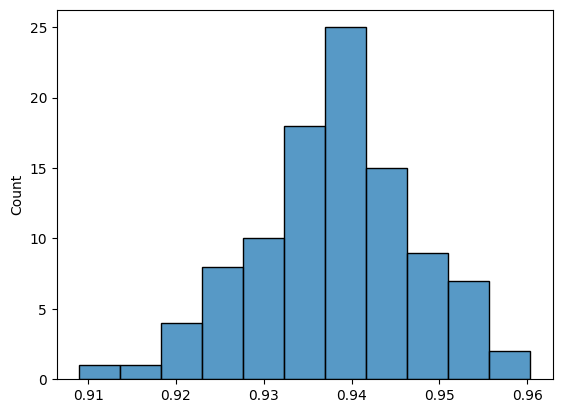

In [41]:
print(np.mean(rocs))
sns.histplot(rocs)
# plt.savefig('rocs_models_gpt_2.pdf')
# plt.savefig('rocs_models_dolly.pdf')

In [42]:
df_fast.write_parquet("sample_data/roberta_nmli_train.parquet")